# Exercises XP Gold: Student Notebook

This notebook is guided to complete the execices on the plateforme.
For each exercise, the **Instructions** are guided and some parts are already coded, and the **Guidance** explains exactly what you must do in complete sentences.

## What will you create
- calculation sheets for metrics like Accuracy, Precision, Recall, and F1-Score based on given confusion matrix values.
- develop strategic proposals that address specific challenges posed by these issues.
- build frameworks for evaluating classification models in different scenarios, especially focusing on the impact of class imbalance and the role of threshold tuning.

## What will you learn
- Understand and interpret the confusion matrix in different scenarios.
- Understand the trade-offs between different evaluation metrics.
- Explore the concepts of cross-validation and learning curves.

## Exercise 1 : Analyzing Confusion Matrix

### Instructions
Imagine you have a dataset for a binary classification problem, such as email spam detection, where emails are classified as either ‘Spam’ or ‘Not Spam’. You are provided with the confusion matrix results of a classifier.
- Define in your own words what True Positives, True Negatives, False Positives, and False Negatives mean in the context of this email spam detection problem.
- Given a confusion matrix with specific values for TP, TN, FP, FN, calculate the Accuracy, Precision, Recall, and F1-Score.
- Discuss how the classifier’s performance would change with a higher number of False Positives compared to False Negatives, and vice versa.

### Guidance
- You will start by writing complete sentences that define True Positives, True Negatives, False Positives, and False Negatives using the spam example.
- You will then run the prefilled code to enter TP, TN, FP, and FN and compute the four metrics.
- You will also generate a calculation sheet that tabulates the metrics so you can export or present the results.
- You will finish by writing a paragraph that explains how increasing False Positives versus increasing False Negatives changes the behavior and implications of the classifier.

In [3]:

# This piece of code is already prefilled, run it to execute it and see the results.
# Enter the confusion matrix values as integers and execute the cell to compute the metrics.

# TP: predicted Spam and actually Spam
# TN: predicted Not Spam and actually Not Spam
# FP: predicted Spam but actually Not Spam
# FN: predicted Not Spam but actually Spam

TP = 50   # replace with your value
TN = 920  # replace with your value
FP = 30   # replace with your value
FN = 20   # replace with your value

total = TP + TN + FP + FN
accuracy  = (TP + TN) / total if total else 0.0
precision = TP / (TP + FP) if (TP + FP) else 0.0
recall    = TP / (TP + FN) if (TP + FN) else 0.0
f1_score  = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1_score, 4))

Accuracy: 0.951
Precision: 0.625
Recall: 0.7143
F1-Score: 0.6667


In [5]:

# This piece of code is already prefilled, run it to execute it and see the results.
# It builds a calculation sheet as a small table and saves it to CSV for reporting.

import pandas as pd

calc_sheet = pd.DataFrame([{
    "TP": TP, "TN": TN, "FP": FP, "FN": FN,
    "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1_score
}])

print(calc_sheet)
csv_path = "confusion_metrics_sheet.csv"
calc_sheet.to_csv(csv_path, index=False)
print("Saved CSV to:", csv_path)

   TP   TN  FP  FN  Accuracy  Precision    Recall  F1-Score
0  50  920  30  20   0.95098      0.625  0.714286  0.666667
Saved CSV to: confusion_metrics_sheet.csv


### Your written analysis
Dans le contexte de spam, un vrai positif c'est lorsque l'email est un spam et que le modèle a prédit que c'est un spam, un vrai négatif c'est quand l'email n'est pas un spam et le modèle a prédit que ce n'est pas un spam. Un faux positif, cest lorsque l'email n'est pas un spam et le modèle a prédit que c'est un spam et un faux négatif est lorsque le modèle a predit que ce n'est pas un spam or ce n'est pas un spam

## Exercise 2 : Evaluating Trade-offs in Metrics

### Instructions
Consider a medical diagnosis application where a model predicts whether patients have a certain disease.
- Explain why high recall is more important than high precision in this medical diagnosis context.
- Describe a scenario where precision becomes more important than recall.
- Discuss the potential consequences of focusing solely on improving accuracy in imbalanced datasets.

### Guidance
- You will write one paragraph that explains why high recall is often prioritized in disease screening and why missing positive cases is risky.
- You will then write one paragraph that presents a realistic scenario where precision is more important than recall and you will justify your choice.
- You will close with one paragraph that explains why accuracy can be misleading on imbalanced datasets and what risks this creates for decisions.

### Your answer
Dans le contexte d'analyse médicale, il y a généralement un déséquilibre de classe entre les patient malade et non malade (il y plus de patient malade que non malade), dans ce contexte, le modèle apprend plus de la classe majoritaire et affiche une précision sur cette classe. Celà peut aller biaisé nos prédiction d'ou l'utilisation du recall

Le scénario ou la précision devient plus important que le rappel, c'est si nos classe sont équilibré, le modèle peut donc apprendre facile des classes et afficher de meilleur précision

Comme on l'avait dit précedemment, lorsqu'il y a un déséquilibre de la classe, le modèle apprend de la classe majoritaire, donc il peut avoir que si nous avons 2 classes, on peut obtenir 100% pour la classe majoritaire et 10 ou même 0% de la classe minoritaire

## Exercise 3 : Understanding Cross-Validation and Learning Curves

### Instructions
You are working on a project with a large dataset that involves predicting housing prices based on various features.
- Explain the difference between K-Fold Cross-Validation and Stratified K-Fold Cross-Validation. Which one would you choose for this task and why?
- Describe what learning curves are and how they can help in understanding the performance of your model.
- Discuss the implications of underfitting and overfitting as observed from learning curves, and how you might address these issues.

### Guidance
- You will begin by explaining the difference between K-Fold and Stratified K-Fold in complete sentences and you will state which approach is suitable for this regression task and why.
- You will then run the prefilled code to generate a learning curve example using synthetic regression data.
- You will finally write a paragraph that interprets the learning curves, explains signs of underfitting and overfitting, and proposes practical actions to address each issue.

#### **Validation croisée K-Fold**

La validation croisée K-Fold consiste à diviser le jeu de données en K sous-ensembles (folds) de taille similaire. À chaque itération :
Un fold est utilisé comme ensemble de test.
Les K-1 folds restants servent à l'entraînement.
Le processus est répété K fois afin que chaque fold soit utilisé une fois comme test.
La performance finale est obtenue en moyennant les résultats des K itérations.
Exemple : Avec K = 5, les données sont divisées en 5 parties. Le modèle est entraîné 5 fois et testé sur une partie différente à chaque fois.

#### **Validation croisée K-Fold stratifiée**

La validation croisée stratifiée conserve la même proportion des classes cibles dans chaque fold que dans l'ensemble de données complet.
Par exemple, si un jeu de données de classification contient :
80 % de classe A
20 % de classe B
alors chaque fold contiendra approximativement les mêmes proportions.
Quel choix pour la prédiction des prix des logements ?
La prédiction du prix des logements est un problème de régression, où la variable cible est continue (prix).
Dans ce cas, on choisit généralement leK-Fold classique car la stratification est principalement conçue pour les problèmes de classification où il faut préserver la distribution des classes.
La validation croisée K-Fold permet d'obtenir une estimation robuste des performances du modèle sur différentes partitions du jeu de données.

### **Courbe d'apprentissage**

Les courbes d'apprentissage représentent l'évolution des performances du modèle en fonction de la quantité de données d'entraînement utilisée. 
Elles affichent généralement :

* Score d'entraînement (Training Score)
* Score de validation (Validation Score)  

en fonction du nombre d'exemples d'entraînement.

**Interprétation**

Lorsque peu de données sont disponibles, le modèle peut obtenir un excellent score sur l'entraînement ;
mais un score faible sur la validation. À mesure que la taille des données augmente, le score d'entraînement diminue légèrement; le score de validation augmente généralement.  
Les courbes d'apprentissage permettent donc d'évaluer la capacité de généralisation du modèle; détecter le surapprentissage ou le sous-apprentissage; savoir si davantage de données pourraient améliorer les performances.

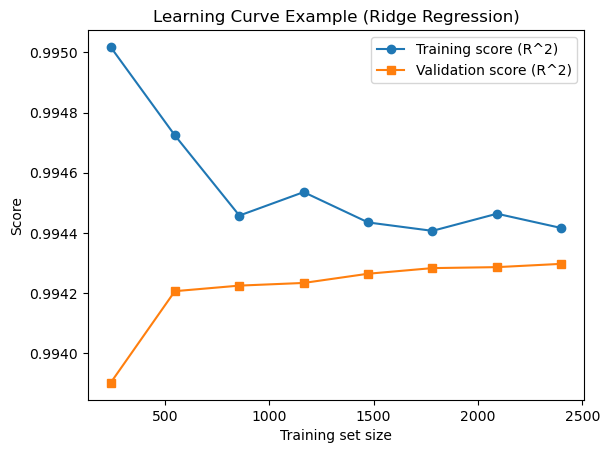

In [6]:

# This piece of code is already prefilled, run it to execute it and see the results.
# It generates a learning curve for a regression model using synthetic data.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import learning_curve, KFold
from sklearn.linear_model import Ridge

X, y = make_regression(n_samples=3000, n_features=20, noise=15.0, random_state=42)
estimator = Ridge(alpha=1.0, random_state=42)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, valid_scores = learning_curve(
    estimator, X, y, cv=cv, scoring="r2", train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=None, shuffle=True, random_state=42
)

train_mean = np.mean(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Training score (R^2)")
plt.plot(train_sizes, valid_mean, marker="s", label="Validation score (R^2)")
plt.xlabel("Training set size")
plt.ylabel("Score")
plt.title("Learning Curve Example (Ridge Regression)")
plt.legend()
plt.show()

### Your interpretation
Les courbes d'apprentissage montrent que les scores d'entraînement et de validation convergent vers une valeur élevée (R² ≈ 0,994). L'écart très faible entre les deux courbes indique une bonne capacité de généralisation du modèle et l'absence de surapprentissage significatif. De plus, les performances élevées sur les ensembles d'entraînement et de validation suggèrent que le modèle ne souffre pas de sous-apprentissage. Le modèle Ridge apparaît donc bien adapté à la tâche de prédiction des prix des logements.

## Exercise 4 : Impact of Class Imbalance on Model Evaluation

### Instructions
Imagine you are working on a dataset for detecting a rare disease where only 2% of the instances are positive cases (have the disease).
- Explain why using accuracy as an evaluation metric might be misleading in this scenario.
- Discuss the importance of precision and recall in the context of this imbalanced dataset.
- Propose strategies you could use to more effectively evaluate and improve the model’s performance in this scenario, considering the imbalance in the dataset.

### Guidance
- You will write one paragraph that explains why a naive classifier can reach high accuracy by predicting the majority class in a highly imbalanced dataset.
- You will then write one paragraph that explains the roles of precision and recall in rare-disease detection and how they reflect different types of errors.
- You will finish with one paragraph that lists strategies to evaluate and improve performance, including stratified splits, class weights, resampling, appropriate metrics, and calibration.

In [7]:

# This piece of code is already prefilled, run it to execute it and see the results.
# It creates a simple illustration of class imbalance and baseline accuracy.

from collections import Counter
import numpy as np

y = np.array([1]*20 + [0]*980)  # 2 percent positives
counter = Counter(y)
majority_class = counter.most_common(1)[0][0]
baseline_accuracy = (y == majority_class).mean()

print("Class distribution:", counter)
print("Majority-class baseline accuracy:", round(baseline_accuracy, 4))
print("Reflect on why this accuracy is high yet uninformative for rare-disease detection.")

Class distribution: Counter({np.int64(0): 980, np.int64(1): 20})
Majority-class baseline accuracy: 0.98
Reflect on why this accuracy is high yet uninformative for rare-disease detection.


### Your answer

#### **Pourquoi la précision (Accuracy) peut être trompeuse**
Dans cet ensemble de données, seulement 2 % des patients sont malades et 98 % sont sains. Il s'agit donc d'un problème de fort déséquilibre des classes. Supposons que notre ensemble possède 1 000 patients, et dans ce total, 20 malades sont classé positive et 980 non malades (classé négatif).  
Imaginons un modèle qui prédit systématiquement que tous les patients sont sains.

La précision (Accuracy) serait :

Accuracy= 980/1000 =98%

Le modèle obtient donc 98 % de précision, ce qui semble excellent. Pourtant, il est incapable de détecter un seul patient malade.
Ainsi, dans les problèmes de maladies rares, la précision seule ne reflète pas la véritable qualité du modèle et peut conduire à des conclusions erronées..

#### **Importance de la précision (Precision) et du rappel (Recall)**

#### **La précision (Precision)**

La précision mesure la proportion de prédictions positives qui sont réellement positives.

Precision= VP / (VP+FP)  
où :  
VP : vrais positifs (malades correctement détectés)
FP : faux positifs (personnes saines diagnostiquées à tort)

Une forte précision signifie que lorsqu'un patient est déclaré malade, il y a de fortes chances qu'il le soit réellement.

#### **Le rappel (Recall ou Sensibilité)**

Le rappel mesure la capacité du modèle à retrouver les cas réellement malades.

Recall= VP  / VP+FN  

où :  
FN : faux négatifs (malades non détectés)
Dans le contexte d'une maladie rare, le rappel est souvent le critère le plus critique.
Par exemple :

Un faux positif entraîne généralement un examen médical supplémentaire.
Un faux négatif signifie qu'un patient malade n'est pas détecté et ne reçoit pas de traitement.

Par conséquent, on cherche généralement à maximiser le rappel tout en maintenant une précision acceptable.

#### **Stratégies pour mieux évaluer et améliorer le modèle**

* Utiliser d'autre métrique comme : F1-Score, la Matrice de confusion, Courbe Precision-Recall
* Rééquilibrer les données : SMOTE, oversampling, undersampling

## Exercise 5 : Role of Threshold Tuning in Classification Models

### Instructions
You are evaluating a binary classification model that predicts whether a bank’s client will default on a loan. The model outputs a probability score between 0 and 1.
- Describe how changing the threshold for classifying a positive case (default) from 0.5 to 0.7 might affect the model’s precision and recall.
- Discuss the potential consequences of setting the threshold too high or too low in the context of loan default prediction.
- Explain how ROC (Receiver Operating Characteristic) curves and AUC (Area Under the Curve) can assist in finding the optimal threshold.

### Guidance
- You will write one paragraph that explains how increasing the threshold generally increases precision and decreases recall, while decreasing the threshold usually does the opposite.
- You will then write one paragraph that explains practical consequences of the threshold choice in loan default prediction for both false positives and false negatives.
- You will finally run the prefilled code to see how precision and recall change with the threshold and how the ROC curve and AUC summarize trade-offs.

Threshold  Precision  Recall
      0.1        0.4     1.0
      0.2        0.5     1.0
      0.3      0.727     1.0
      0.4      0.889     1.0
      0.5        1.0     1.0
      0.6        1.0     1.0
      0.7        1.0   0.875
      0.8        1.0     0.5
      0.9        1.0   0.125


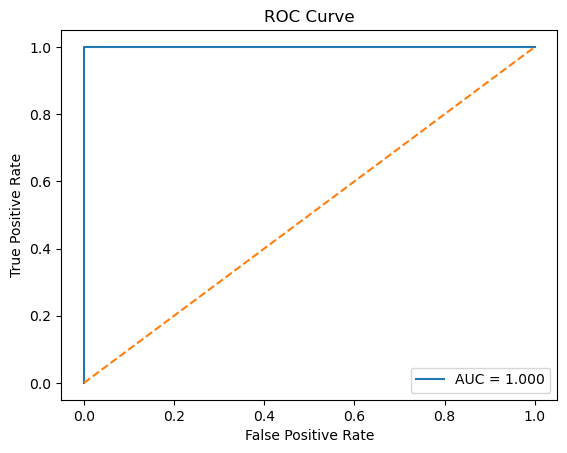

In [8]:

# This piece of code is already prefilled, run it to execute it and see the results.
# It evaluates precision and recall across thresholds and plots an ROC curve.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, roc_curve, auc

# Example placeholders. Replace with your own true labels and predicted probabilities if available.
y_true = np.array([0,1,0,1,0,1,0,0,1,0,1,0,0,1,0,0,1,0,1,0])
y_pred_proba = np.array([0.10,0.82,0.12,0.65,0.28,0.73,0.33,0.21,0.88,0.19,0.77,0.40,0.27,0.91,0.31,0.18,0.79,0.29,0.84,0.22])

thresholds = np.linspace(0.1, 0.9, 9)
rows = []
for t in thresholds:
    y_pred = (y_pred_proba >= t).astype(int)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    rows.append((round(t,2), round(prec,3), round(rec,3)))

print("Threshold  Precision  Recall")
for r in rows:
    print(f"{r[0]:>9}  {r[1]:>9}  {r[2]:>6}")

fpr, tpr, roc_th = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Please provide answers to questions above
> To-Do: Please write your complete answer here